# Metric Scale Analysis — v3 Heldout Evaluation

Two-stage analysis of metric scale prediction on the 64-sample live heldout set.

**Stage 1**: Direct MetricScaleDecoder output — predicted [W, H, D] vs GT [W, H, D], per-dimension error.  
**Stage 2**: Mesh bounding box accuracy — isotropic scaling (production) vs per-axis rank-matched scaling (upper bound). Quantifies the cost of wrong voxel aspect ratios from SS.

In [1]:
import os, sys
os.environ.setdefault('LIDRA_SKIP_INIT', '1')
os.environ.setdefault('ATTN_BACKEND', 'sdpa')
os.environ.setdefault('SPARSE_ATTN_BACKEND', 'sdpa')

# Run from repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print('Working dir:', os.getcwd())

Working dir: /mnt/source/sam-3d-objects


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import Subset

from sam3d_objects.data.dataset.metric.nocs import OmniNOCSReal275Dataset
from sam3d_objects.model.backbone.metric_scale_decoder import MetricScaleDecoder
from sam3d_objects.model.backbone.scale_head import (
    MetricScaleHead, _ScaleAugmentedEmbedderProxy, extract_ss_scale_features,
)
from sam3d_objects.training.finetune_metric_scale import freeze_pipeline, load_metric_checkpoint

print('Imports OK')

Imports OK


## Configuration
Edit `CHECKPOINT` to switch between checkpoints (v3_best, ss_ratio_v1_best, etc.).

In [3]:
CHECKPOINT    = 'artifacts/metric_scale/checkpoints/nocs_sceneholdout_ss_ratio_v1_best.pt'
CONFIG        = 'checkpoints/hf/pipeline.yaml'
ANNOTATIONS   = '/mnt/source/datasets_sam3d/OmniNOCS/omninocs_release_nocs_real275'
RGB_ROOT      = '/mnt/source/datasets_sam3d/OmniNOCS/real_test'
STAGE1_STEPS  = 4
STAGE2_STEPS  = 1
HELDOUT_N     = 64     # must match training --heldout-samples
DEVICE        = 'cuda'

# Category colour palette
CATEGORY_COLORS = {
    'bottle': '#e41a1c',
    'bowl':   '#377eb8',
    'camera': '#4daf4a',
    'can':    '#ff7f00',
    'cup':    '#984ea3',
    'laptop': '#a65628',
}

## Load Pipeline, Heads, Dataset

In [4]:
from hydra.utils import instantiate
from omegaconf import OmegaConf

print('Loading pipeline...')
config = OmegaConf.load(CONFIG)
config.workspace_dir = os.path.dirname(CONFIG)
config.compile_model = False
config.device = DEVICE
pipeline = instantiate(config)
freeze_pipeline(pipeline)
print('Pipeline loaded.')

scale_head    = MetricScaleHead().to(DEVICE).eval()
scale_decoder = MetricScaleDecoder().to(DEVICE).eval()
load_metric_checkpoint(CHECKPOINT, scale_head, scale_decoder)
print(f'Checkpoint loaded: {CHECKPOINT}')

Loading pipeline...


2026-05-21 20:16:38.069 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA A10


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-05-21 20:16:43.421 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:51: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:100: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:166: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functiona

[SPARSE][CONV] spconv algo: auto


/opt/conda/envs/sam3d/lib/python3.11/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
2026-05-21 20:16:52.306 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-05-21 20:16:52.306 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-05-21 20:16:52.461 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


model.pt:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

/opt/conda/envs/sam3d/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-05-21 20:17:06.460 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-05-21 20:17:06.462 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - self.device: cuda
2026-05-21 20:17:06.462 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:103 - CUDA_VISIBLE_DEVICES: None
2026-05-21 20:17:06.463 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:104 - Actually using GPU: 0
2026-05-21 20:17:06.463 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:299 - Using pose decoder: ScaleShiftInvariant
2026-05-21 20:17:06.463 | INFO     | sam3d_objects.pipeline.inference

Pipeline loaded.
Loaded metric scale checkpoint from artifacts/metric_scale/checkpoints/nocs_sceneholdout_ss_ratio_v1_best.pt
Checkpoint loaded: artifacts/metric_scale/checkpoints/nocs_sceneholdout_ss_ratio_v1_best.pt


In [5]:
# Replicate the training heldout split:
# --split-group record --heldout-samples 64 --seed 0 (no --shuffle-split)
# => heldout = last 64 records in dataset order

full_dataset = OmniNOCSReal275Dataset(
    annotations_root=ANNOTATIONS,
    rgb_root=RGB_ROOT,
    split='train',
    min_mask_pixels=500,
)
n = len(full_dataset)
heldout_indices = list(range(n - HELDOUT_N, n))
heldout_dataset = Subset(full_dataset, heldout_indices)
print(f'Full dataset: {n}  |  Heldout: {len(heldout_dataset)} samples')

Full dataset: 16118  |  Heldout: 64 samples


## Run Inference on All 64 Heldout Samples

Collects per-sample:
- `pred_dims`: raw MetricScaleDecoder output [W, H, D] in metres  
- `gt_dims`: ground-truth [W, H, D] in metres  
- `verts_canonical`: mesh vertices in unit-cube canonical space  
- `faces`: triangle indices  

In [6]:
import torch.nn.functional as F

def run_sample(item):
    """Returns a results dict for one heldout sample."""
    image   = item['image']             # np [H,W,4] uint8
    gt_dims = np.array(item['metric_dims'], dtype=np.float32)  # [W, H, D]
    category = item.get('category', 'unknown')

    with torch.no_grad():
        # --- Depth / conditioning ---
        pointmap_dict   = pipeline.compute_pointmap(image)
        ss_input_dict   = pipeline.preprocess_image(
            image, pipeline.ss_preprocessor,
            pointmap=pointmap_dict['pointmap'])
        slat_input_dict = pipeline.preprocess_image(image, pipeline.slat_preprocessor)

        # --- Stage 1: SS ---
        ss_ret = pipeline.sample_sparse_structure(
            ss_input_dict, inference_steps=STAGE1_STEPS, use_distillation=False)

        # --- Metric scale token ---
        ss_feats = extract_ss_scale_features(ss_ret)
        if ss_feats is not None:
            ss_feats = ss_feats.to(DEVICE)
        scale_token = scale_head(
            ss_ret['shape'],
            ss_feats,
            ss_input_dict.get('pointmap_scale'),
            ss_input_dict.get('pointmap_shift'),
        )

        # --- Inject into SLAT conditioning ---
        token_norm   = F.layer_norm(scale_token, [scale_token.shape[-1]])
        slat_backbone = pipeline._get_slat_backbone()
        orig_bb_emb  = orig_ext_emb = None
        if slat_backbone is not None:
            orig_bb_emb = slat_backbone.condition_embedder
            slat_backbone.condition_embedder = _ScaleAugmentedEmbedderProxy(orig_bb_emb, token_norm)
        cond_embs = getattr(pipeline, 'condition_embedders', {})
        orig_ext_emb = cond_embs.get('slat_condition_embedder')
        if orig_ext_emb is not None:
            pipeline.condition_embedders['slat_condition_embedder'] = \
                _ScaleAugmentedEmbedderProxy(orig_ext_emb, token_norm)

        try:
            slat = pipeline.sample_slat(
                slat_input_dict, ss_ret['coords'],
                inference_steps=STAGE2_STEPS, use_distillation=False)
        finally:
            if orig_bb_emb is not None and slat_backbone is not None:
                slat_backbone.condition_embedder = orig_bb_emb
            if orig_ext_emb is not None:
                pipeline.condition_embedders['slat_condition_embedder'] = orig_ext_emb

        # --- Decode mesh ---
        decoded    = pipeline.decode_slat(slat, formats=['mesh'])
        mesh       = decoded['mesh'][0]

        # --- Metric prediction [W, H, D] ---
        log_dims   = scale_decoder(slat.feats, scale_token, slat.coords[:, 0])
        pred_dims  = torch.exp(log_dims[0]).cpu().numpy()  # [3] W,H,D

    verts = mesh.vertices.float().cpu().numpy()  # [N, 3]
    faces = mesh.faces.int().cpu().numpy()        # [F, 3]

    return {
        'category':       category,
        'gt_dims':        gt_dims,          # [W, H, D] metres
        'pred_dims':      pred_dims,        # [W, H, D] metres
        'verts_canonical': verts,
        'faces':           faces,
    }

print('run_sample defined')

run_sample defined


In [7]:
results = []
skipped = 0

for i in tqdm(range(len(heldout_dataset)), desc='Running inference'):
    item = heldout_dataset[i]
    try:
        r = run_sample(item)
        results.append(r)
    except Exception as e:
        print(f'  [skip {i}] {e}')
        skipped += 1

print(f'\nDone. {len(results)} samples collected, {skipped} skipped.')

Running inference:   0%|          | 0/64 [00:00<?, ?it/s]

2026-05-21 20:21:12.552 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:668 - Sampling sparse structure: inference_steps=4, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-05-21 20:21:12.553 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-21 20:21:12.695 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Condition embedder finishes!
2026-05-21 20:21:14.499 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:718 - Downsampled coords from 15068 to 13234
2026-05-21 20:21:14.506 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:749 - Sampling sparse latent: inference_steps=1, strength=1, interval=[0, 500], rescale_t=1
2026-05-21 20:21:14.507 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Running condition embedder ...
2026-05-21 20:21:14.585 | INFO     | sam3d_o


Done. 64 samples collected, 0 skipped.


---
## Stage 1 — MetricScaleDecoder: Predicted vs GT [W, H, D]

The decoder outputs three values corresponding directly to GT W (width), H (height), D (depth) in metres.

In [8]:
# Build a flat DataFrame for Stage 1
rows = []
for r in results:
    for dim_idx, dim_name in enumerate(['W', 'H', 'D']):
        rows.append({
            'category':  r['category'],
            'dim':       dim_name,
            'gt':        r['gt_dims'][dim_idx],
            'pred':      r['pred_dims'][dim_idx],
            'abs_err':   abs(r['pred_dims'][dim_idx] - r['gt_dims'][dim_idx]),
            'pct_err':   abs(r['pred_dims'][dim_idx] - r['gt_dims'][dim_idx]) /
                         max(r['gt_dims'][dim_idx], 1e-6) * 100,
        })
df1 = pd.DataFrame(rows)

# Summary table
summary1 = df1.groupby('dim').agg(
    MAPE=('pct_err', 'mean'),
    Median_APE=('pct_err', 'median'),
    Mean_abs_cm=('abs_err', lambda x: x.mean() * 100),
).round(3)
print('=== Stage 1: Per-dimension prediction error ===')
print(summary1.to_string())

overall_mape = df1['pct_err'].mean()
print(f'\nOverall MAPE across W,H,D: {overall_mape:.3f}%')

=== Stage 1: Per-dimension prediction error ===
          MAPE  Median_APE  Mean_abs_cm
dim                                    
D    19.389000      12.712        2.175
H    42.946999      13.231        3.879
W    52.540001      13.627        4.638

Overall MAPE across W,H,D: 38.292%


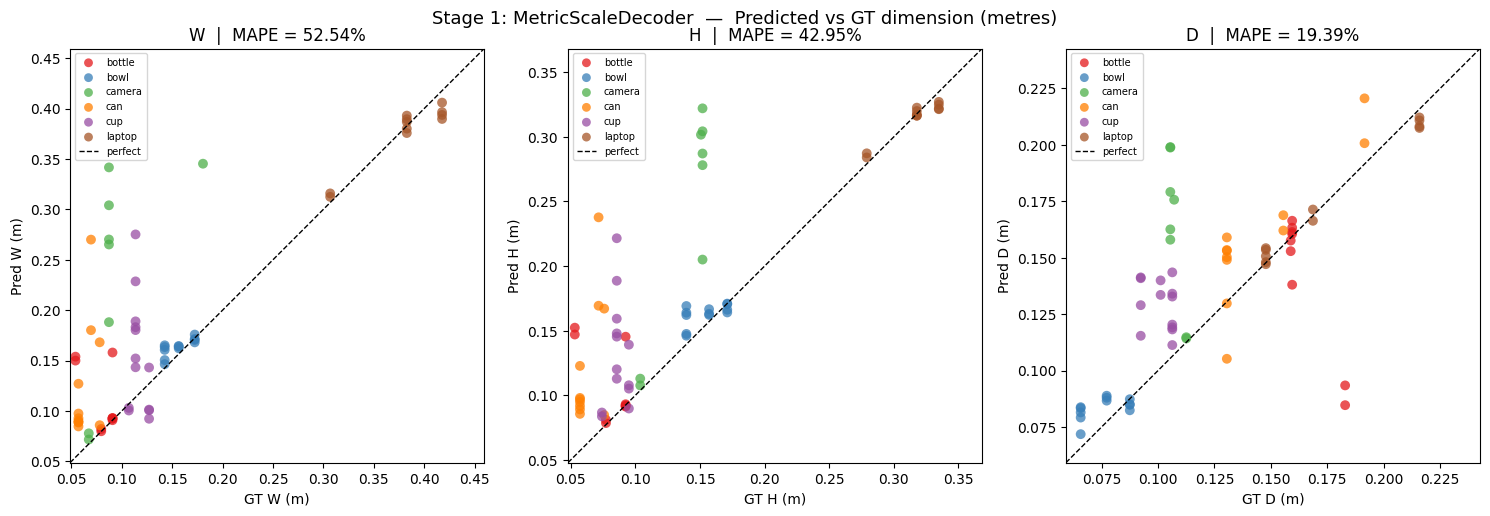

In [9]:
# --- Scatter: Predicted vs GT per dimension ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Stage 1: MetricScaleDecoder  —  Predicted vs GT dimension (metres)', fontsize=13)

for ax, dim_name in zip(axes, ['W', 'H', 'D']):
    sub = df1[df1['dim'] == dim_name]
    for cat, grp in sub.groupby('category'):
        col = CATEGORY_COLORS.get(cat, 'gray')
        ax.scatter(grp['gt'], grp['pred'], c=col, label=cat, alpha=0.75, s=50, edgecolors='none')
    lo = min(sub['gt'].min(), sub['pred'].min()) * 0.9
    hi = max(sub['gt'].max(), sub['pred'].max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='perfect')
    ax.set_xlabel(f'GT {dim_name} (m)')
    ax.set_ylabel(f'Pred {dim_name} (m)')
    mape = sub['pct_err'].mean()
    ax.set_title(f'{dim_name}  |  MAPE = {mape:.2f}%')
    ax.legend(fontsize=7, markerscale=0.9)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig('/mnt/source/sam-3d-objects/artifacts/metric_scale/eval_v3_notebook/stage1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# --- Per-category MAPE breakdown (Stage 1) ---
cat_dim = df1.groupby(['category', 'dim'])['pct_err'].mean().unstack('dim').round(2)
cat_dim['mean'] = cat_dim.mean(axis=1).round(2)
print('=== Stage 1: Per-category MAPE (%) per dimension ===')
print(cat_dim.to_string())

=== Stage 1: Per-category MAPE (%) per dimension ===
dim               D          H           W       mean
category                                             
bottle    14.360000  47.889999   49.599998  37.279999
bowl      13.410000   7.180000    5.920000   8.840000
camera    52.349998  66.500000  147.889999  88.910004
can       12.630000  90.089996   95.330002  66.019997
cup       28.299999  52.860001   44.619999  41.930000
laptop     2.290000   1.930000    3.020000   2.410000


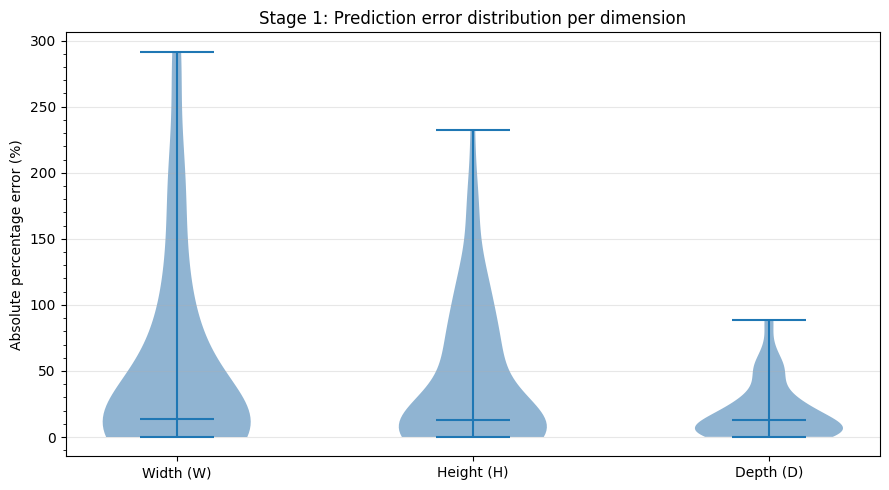

In [11]:
# --- Error distribution violin plots (Stage 1) ---
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(9, 5))
dim_order = ['W', 'H', 'D']
data_by_dim = [df1[df1['dim'] == d]['pct_err'].values for d in dim_order]

parts = ax.violinplot(data_by_dim, positions=[1, 2, 3], showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('#4682b4')
    pc.set_alpha(0.6)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Width (W)', 'Height (H)', 'Depth (D)'])
ax.set_ylabel('Absolute percentage error (%)')
ax.set_title('Stage 1: Prediction error distribution per dimension')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
#plt.savefig('artifacts/metric_scale/eval_v3_notebook/stage1_violin.png', dpi=150, bbox_inches='tight')
plt.show()

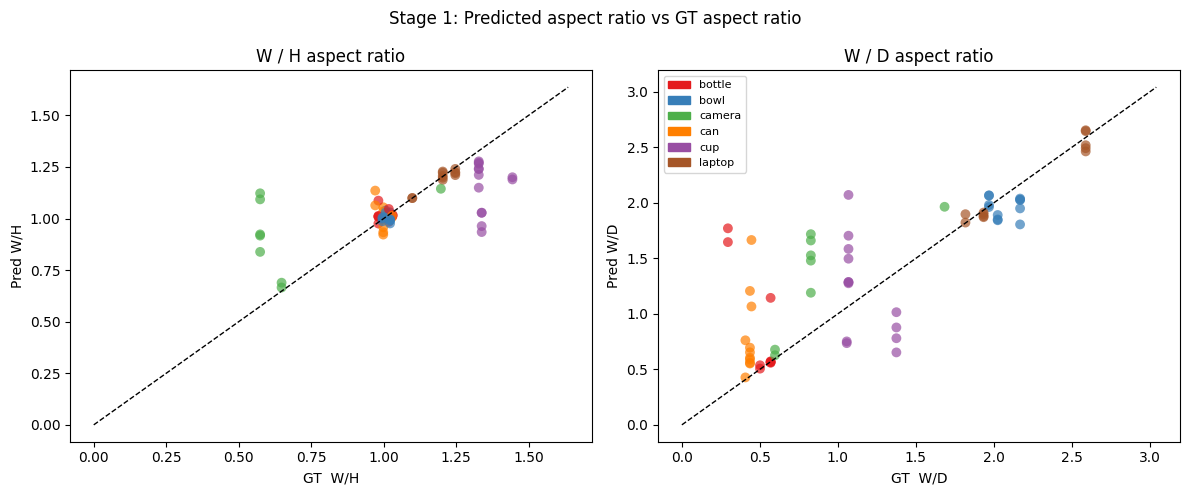

In [12]:
# --- Aspect ratio accuracy: predicted ratio vs GT ratio ---
# Visualise how well the decoder captures the shape proportions (W:H, W:D)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Stage 1: Predicted aspect ratio vs GT aspect ratio')

for ax, (num_dim, den_dim) in zip(axes, [(0, 1), (0, 2)]):
    num_lbl = ['W', 'H', 'D'][num_dim]
    den_lbl = ['W', 'H', 'D'][den_dim]
    for r in results:
        cat = r['category']
        col = CATEGORY_COLORS.get(cat, 'gray')
        gt_ratio   = r['gt_dims'][num_dim]   / max(r['gt_dims'][den_dim],   1e-6)
        pred_ratio = r['pred_dims'][num_dim] / max(r['pred_dims'][den_dim], 1e-6)
        ax.scatter(gt_ratio, pred_ratio, c=col, alpha=0.7, s=50, edgecolors='none')
    lo = 0
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1]) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel(f'GT  {num_lbl}/{den_lbl}')
    ax.set_ylabel(f'Pred {num_lbl}/{den_lbl}')
    ax.set_title(f'{num_lbl} / {den_lbl} aspect ratio')

# Legend
patches = [mpatches.Patch(color=c, label=k) for k, c in CATEGORY_COLORS.items()]
axes[-1].legend(handles=patches, fontsize=8)
plt.tight_layout()
# plt.savefig('artifacts/metric_scale/eval_v3_notebook/stage1_aspect_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Stage 2 — Mesh Bounding Box: Isotropic vs Per-Axis Scaling

The canonical mesh has `max(bbox) ≈ 1.0` by construction (FlexiCubes).  
Two scaling strategies bring it into metric space:

- **Isotropic** (production): `s = max(W_pred, H_pred, D_pred)` — all vertices × s
- **Per-axis** (upper bound): rank-sort predicted dims descending, rank-sort mesh extents descending, scale each axis so its extent = corresponding predicted dim

Both results are rank-sorted for comparison against GT (largest mesh extent ↔ largest GT dim).

In [13]:
def mesh_bbox_extents(verts):
    return verts.max(axis=0) - verts.min(axis=0)  # [3]

def apply_iso_scale(verts, pred_dims):
    s = pred_dims.max()
    return verts * s

def apply_peraxis_scale(verts, pred_dims):
    raw_ext  = mesh_bbox_extents(verts)          # [3] per-axis extents
    pred_sorted = np.sort(pred_dims)[::-1].copy() # [3] desc
    ext_rank    = np.argsort(raw_ext)[::-1]       # axis indices sorted by extent desc
    scale_factors = np.ones(3, dtype=np.float64)
    center = (verts.min(axis=0) + verts.max(axis=0)) / 2.0
    for rank, axis in enumerate(ext_rank):
        if raw_ext[axis] > 1e-6:
            scale_factors[axis] = pred_sorted[rank] / raw_ext[axis]
        else:
            scale_factors[axis] = 1.0
    return center + (verts - center) * scale_factors

# Compute Stage 2 metrics for all results
rows2 = []
for r in results:
    verts     = r['verts_canonical']
    pred_dims = r['pred_dims']
    gt_sorted = np.sort(r['gt_dims'])[::-1].copy()    # [3] desc

    # Isotropic
    v_iso   = apply_iso_scale(verts, pred_dims)
    ext_iso = np.sort(mesh_bbox_extents(v_iso))[::-1]  # [3] desc

    # Per-axis
    v_perax   = apply_peraxis_scale(verts, pred_dims)
    ext_perax = np.sort(mesh_bbox_extents(v_perax))[::-1]  # [3] desc

    for rank, rank_label in enumerate(['largest', 'middle', 'smallest']):
        rows2.append({
            'category': r['category'],
            'rank':     rank_label,
            'gt':       gt_sorted[rank],
            'iso':      ext_iso[rank],
            'peraxis':  ext_perax[rank],
            'iso_pct':    abs(ext_iso[rank]   - gt_sorted[rank]) / max(gt_sorted[rank], 1e-6) * 100,
            'peraxis_pct':abs(ext_perax[rank] - gt_sorted[rank]) / max(gt_sorted[rank], 1e-6) * 100,
        })

df2 = pd.DataFrame(rows2)

# Overall summary
# Per-sample MAPE (mean over 3 ranks)
per_sample_iso    = df2.groupby(df2.index // 3)['iso_pct'].mean()
per_sample_perax  = df2.groupby(df2.index // 3)['peraxis_pct'].mean()

print('=== Stage 2: Mesh Bounding Box MAPE ===')
print(f'  Isotropic  MAPE: {per_sample_iso.mean():.2f}%  (median {per_sample_iso.median():.2f}%)')
print(f'  Per-axis   MAPE: {per_sample_perax.mean():.2f}%  (median {per_sample_perax.median():.2f}%)')
print(f'  Gap (iso - peraxis): {per_sample_iso.mean() - per_sample_perax.mean():+.2f}pp')

print()
s2 = df2.groupby('rank').agg(
    iso_MAPE=('iso_pct', 'mean'),
    peraxis_MAPE=('peraxis_pct', 'mean'),
).round(2)
s2['gap_pp'] = (s2['iso_MAPE'] - s2['peraxis_MAPE']).round(2)
print(s2.to_string())

=== Stage 2: Mesh Bounding Box MAPE ===
  Isotropic  MAPE: 29.12%  (median 15.87%)
  Per-axis   MAPE: 33.98%  (median 12.61%)
  Gap (iso - peraxis): -4.85pp

           iso_MAPE  peraxis_MAPE  gap_pp
rank                                     
largest   23.930000         23.28    0.65
middle    27.879999         43.23  -15.35
smallest  35.549999         35.41    0.14


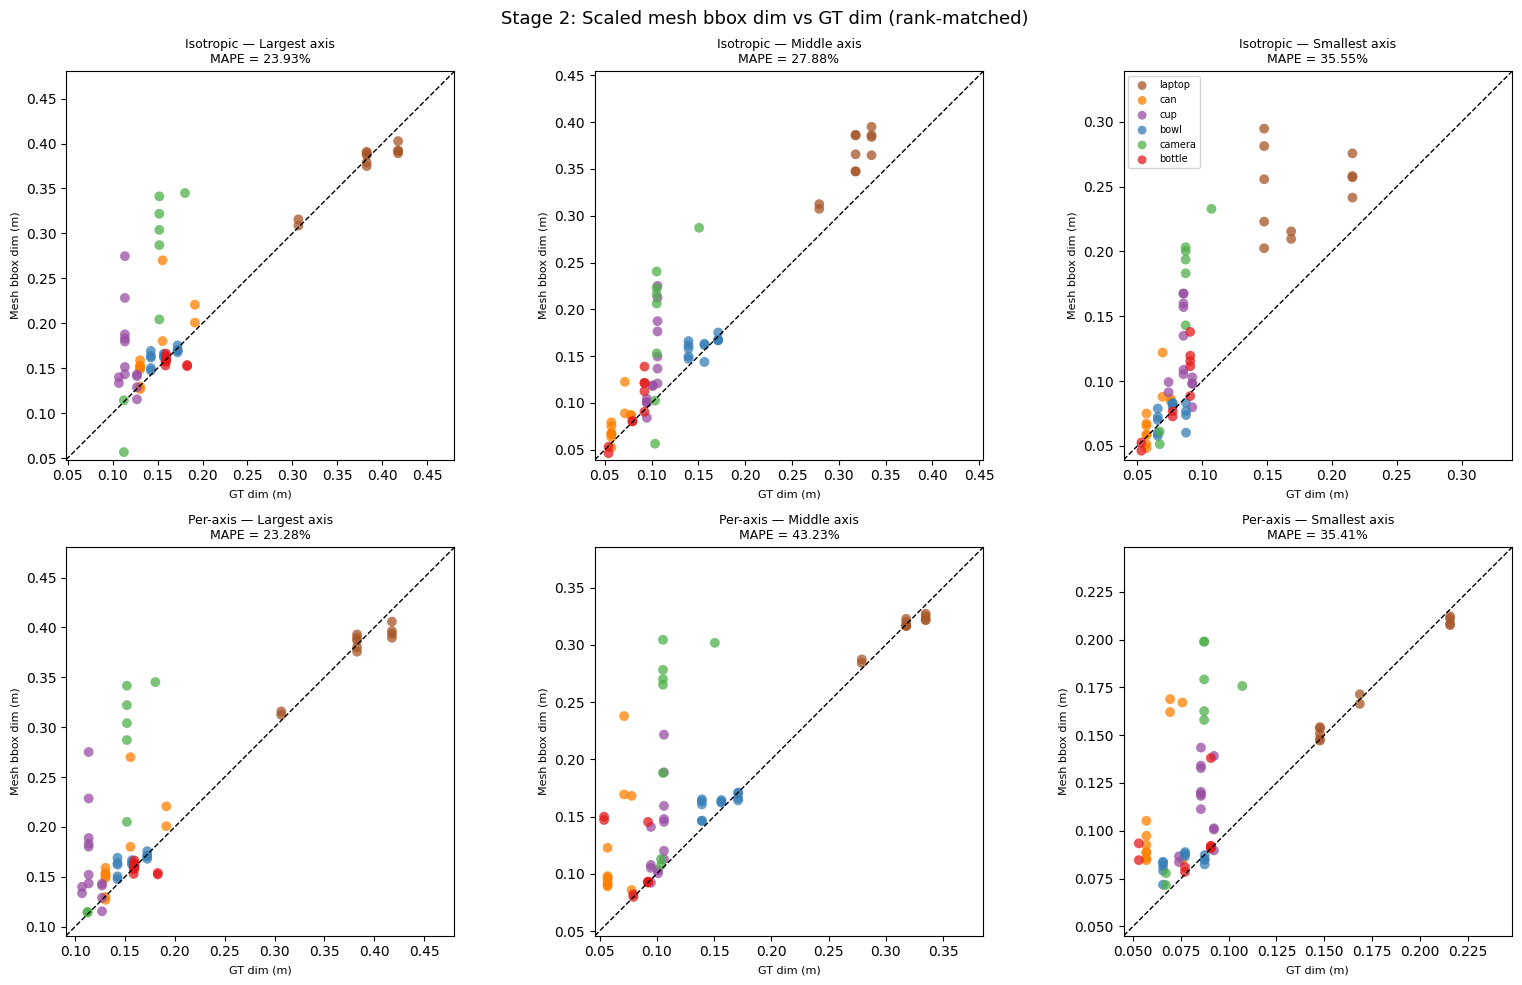

In [14]:
# --- Stage 2 scatter: mesh bbox dims vs GT dims (iso and per-axis) ---
rank_order  = ['largest', 'middle', 'smallest']
rank_labels = ['Largest axis', 'Middle axis', 'Smallest axis']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Stage 2: Scaled mesh bbox dim vs GT dim (rank-matched)', fontsize=13)

for col_idx, (rank, rank_label) in enumerate(zip(rank_order, rank_labels)):
    sub = df2[df2['rank'] == rank]

    for row_idx, (y_col, strategy) in enumerate([('iso', 'Isotropic'), ('peraxis', 'Per-axis')]):
        ax = axes[row_idx][col_idx]
        for cat in sub['category'].unique():
            grp = sub[sub['category'] == cat]
            col = CATEGORY_COLORS.get(cat, 'gray')
            ax.scatter(grp['gt'], grp[y_col], c=col, label=cat, alpha=0.75, s=50, edgecolors='none')
        lo = min(sub['gt'].min(), sub[y_col].min()) * 0.85
        hi = max(sub['gt'].max(), sub[y_col].max()) * 1.15
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        mape = sub[f'{y_col}_pct'].mean()
        ax.set_title(f'{strategy} — {rank_label}\nMAPE = {mape:.2f}%', fontsize=9)
        ax.set_xlabel('GT dim (m)', fontsize=8)
        ax.set_ylabel('Mesh bbox dim (m)', fontsize=8)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect('equal')
        if col_idx == 2 and row_idx == 0:
            ax.legend(fontsize=7, markerscale=0.9)

plt.tight_layout()
# plt.savefig('artifacts/metric_scale/eval_v3_notebook/stage2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

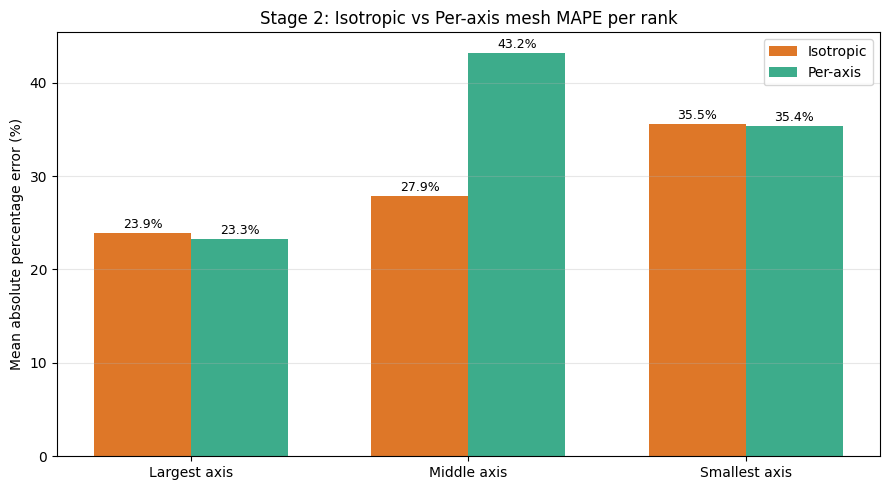

Aspect ratio gap (overall): -4.85pp


In [15]:
# --- Gap bar chart: iso vs per-axis MAPE per rank ---
fig, ax = plt.subplots(figsize=(9, 5))

x      = np.arange(3)
width  = 0.35
iso_means   = [df2[df2['rank'] == r]['iso_pct'].mean()    for r in rank_order]
perax_means = [df2[df2['rank'] == r]['peraxis_pct'].mean() for r in rank_order]

b1 = ax.bar(x - width/2, iso_means,   width, label='Isotropic',  color='#d95f02', alpha=0.85)
b2 = ax.bar(x + width/2, perax_means, width, label='Per-axis',   color='#1b9e77', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Largest axis', 'Middle axis', 'Smallest axis'])
ax.set_ylabel('Mean absolute percentage error (%)')
ax.set_title('Stage 2: Isotropic vs Per-axis mesh MAPE per rank')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('artifacts/metric_scale/eval_v3_notebook/stage2_gap_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Aspect ratio gap (overall): {np.mean(iso_means) - np.mean(perax_means):+.2f}pp')

=== Stage 2: Per-category mesh MAPE ===
           iso_MAPE  peraxis_MAPE  gap_pp
category                                 
laptop    20.330000          2.41   17.92
cup       42.180000         36.37    5.81
bowl       8.390000          8.83   -0.44
camera    80.550003         84.26   -3.71
bottle    13.240000         24.31  -11.07
can       20.680000         61.47  -40.79


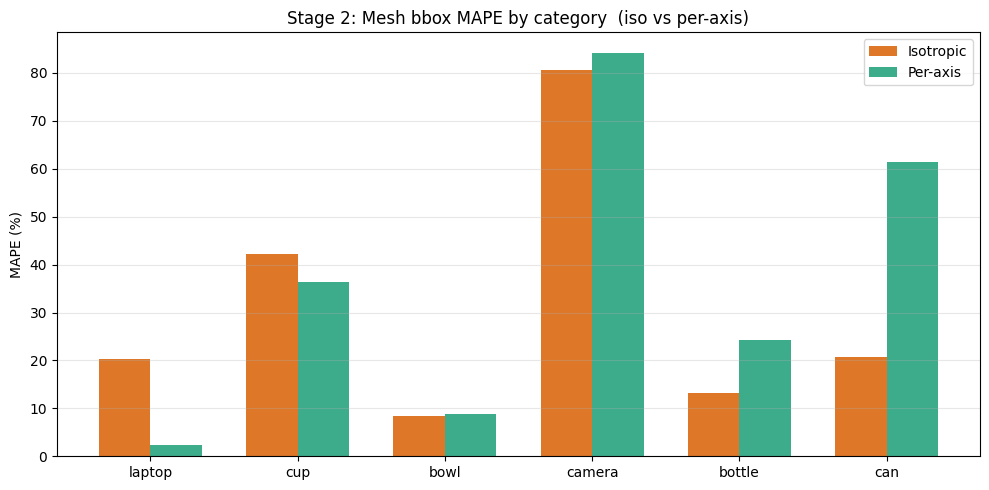

In [16]:
# --- Per-category breakdown (Stage 2) ---
cat_s2 = df2.groupby('category').agg(
    iso_MAPE   =('iso_pct',    'mean'),
    peraxis_MAPE=('peraxis_pct','mean'),
).round(2)
cat_s2['gap_pp'] = (cat_s2['iso_MAPE'] - cat_s2['peraxis_MAPE']).round(2)
cat_s2 = cat_s2.sort_values('gap_pp', ascending=False)
print('=== Stage 2: Per-category mesh MAPE ===')
print(cat_s2.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
cats = cat_s2.index.tolist()
x2   = np.arange(len(cats))
ax.bar(x2 - width/2, cat_s2['iso_MAPE'],    width, label='Isotropic',  color='#d95f02', alpha=0.85)
ax.bar(x2 + width/2, cat_s2['peraxis_MAPE'],width, label='Per-axis',   color='#1b9e77', alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(cats)
ax.set_ylabel('MAPE (%)')
ax.set_title('Stage 2: Mesh bbox MAPE by category  (iso vs per-axis)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('artifacts/metric_scale/eval_v3_notebook/stage2_category_bars.png', dpi=150, bbox_inches='tight')
plt.show()

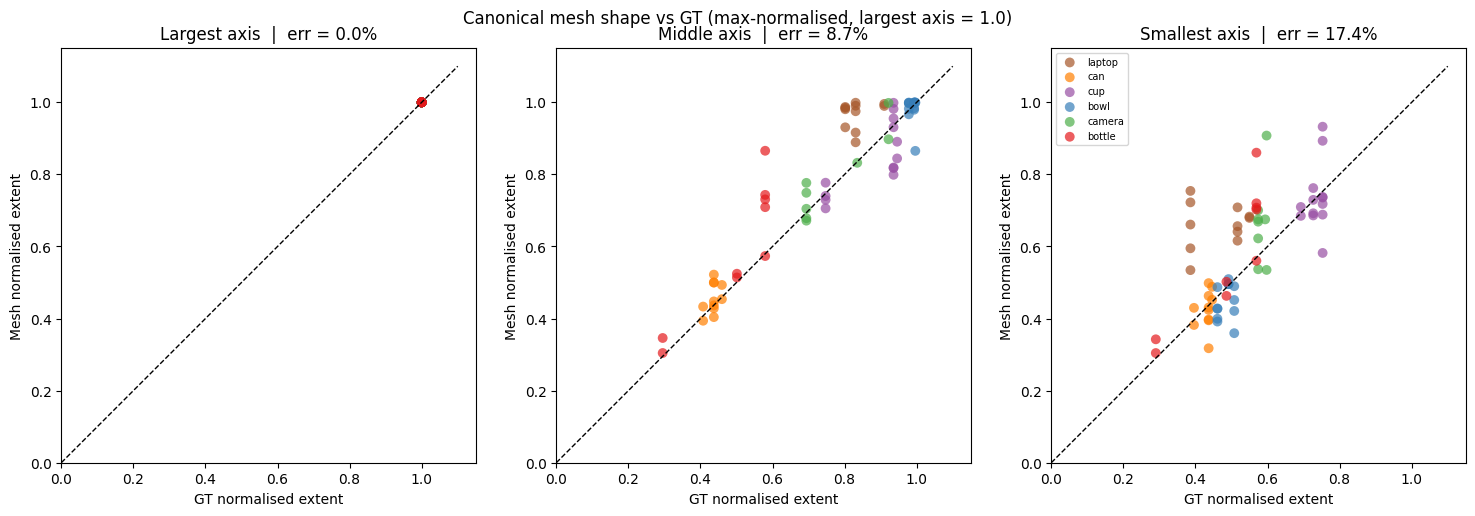

Canonical mesh shape error (before any scaling):
rank
largest      0.00
middle       8.69
smallest    17.43


In [17]:
# --- Canonical mesh shape: actual voxel aspect ratio vs GT ---
# Shows how far the SS mesh extents are from the GT proportions (before any scaling)

rows3 = []
for r in results:
    raw_ext    = mesh_bbox_extents(r['verts_canonical'])          # [3]
    raw_sorted = np.sort(raw_ext)[::-1].copy()                    # [3] desc
    gt_sorted  = np.sort(r['gt_dims'])[::-1].copy()               # [3] desc

    # Normalise both to max=1 for shape-only comparison
    raw_norm = raw_sorted / max(raw_sorted[0], 1e-6)
    gt_norm  = gt_sorted  / max(gt_sorted[0],  1e-6)

    for rank, rank_label in enumerate(['largest', 'middle', 'smallest']):
        rows3.append({
            'category': r['category'],
            'rank':     rank_label,
            'gt_norm':  gt_norm[rank],
            'raw_norm': raw_norm[rank],
            'pct_err':  abs(raw_norm[rank] - gt_norm[rank]) / max(gt_norm[rank], 1e-6) * 100,
        })

df3 = pd.DataFrame(rows3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Canonical mesh shape vs GT (max-normalised, largest axis = 1.0)', fontsize=12)

for ax, rank in zip(axes, rank_order):
    sub = df3[df3['rank'] == rank]
    for cat in sub['category'].unique():
        grp = sub[sub['category'] == cat]
        col = CATEGORY_COLORS.get(cat, 'gray')
        ax.scatter(grp['gt_norm'], grp['raw_norm'], c=col, label=cat, alpha=0.7, s=50, edgecolors='none')
    ax.plot([0, 1.1], [0, 1.1], 'k--', lw=1)
    ax.set_xlabel('GT normalised extent')
    ax.set_ylabel('Mesh normalised extent')
    mape = sub['pct_err'].mean()
    ax.set_title(f'{rank.capitalize()} axis  |  err = {mape:.1f}%')
    ax.set_xlim(0, 1.15); ax.set_ylim(0, 1.15)
    ax.set_aspect('equal')
    if rank == 'smallest':
        ax.legend(fontsize=7)

plt.tight_layout()
# plt.savefig('artifacts/metric_scale/eval_v3_notebook/canonical_shape.png', dpi=150, bbox_inches='tight')
plt.show()

print('Canonical mesh shape error (before any scaling):')
print(df3.groupby('rank')['pct_err'].mean().round(2).to_string())

---
## Summary

In [18]:
print('=' * 60)
print(f'CHECKPOINT: {os.path.basename(CHECKPOINT)}')
print(f'Samples:    {len(results)}')
print('=' * 60)

print('\n--- Stage 1: MetricScaleDecoder (pred [W,H,D] vs GT) ---')
for d in ['W', 'H', 'D']:
    mape = df1[df1['dim'] == d]['pct_err'].mean()
    print(f'  {d}: {mape:.2f}%')
print(f'  Overall: {df1["pct_err"].mean():.2f}%')

print('\n--- Stage 2: Mesh bbox (iso vs per-axis) ---')
print(f'  Isotropic MAPE:  {per_sample_iso.mean():.2f}%')
print(f'  Per-axis  MAPE:  {per_sample_perax.mean():.2f}%')
print(f'  Aspect ratio gap: {per_sample_iso.mean() - per_sample_perax.mean():+.2f}pp')

print('\n--- Stage 2 per category ---')
print(cat_s2[['iso_MAPE', 'peraxis_MAPE', 'gap_pp']].to_string())
print('=' * 60)

CHECKPOINT: nocs_sceneholdout_ss_ratio_v1_best.pt
Samples:    64

--- Stage 1: MetricScaleDecoder (pred [W,H,D] vs GT) ---
  W: 52.54%
  H: 42.95%
  D: 19.39%
  Overall: 38.29%

--- Stage 2: Mesh bbox (iso vs per-axis) ---
  Isotropic MAPE:  29.12%
  Per-axis  MAPE:  33.98%
  Aspect ratio gap: -4.85pp

--- Stage 2 per category ---
           iso_MAPE  peraxis_MAPE  gap_pp
category                                 
laptop    20.330000          2.41   17.92
cup       42.180000         36.37    5.81
bowl       8.390000          8.83   -0.44
camera    80.550003         84.26   -3.71
bottle    13.240000         24.31  -11.07
can       20.680000         61.47  -40.79


In [19]:
# Save all results to JSONL for later analysis
import json
os.makedirs('artifacts/metric_scale/eval_v3_notebook-ratio', exist_ok=True)

out_path = 'artifacts/metric_scale/eval_v3_notebook-ratio/results.jsonl'
with open(out_path, 'w') as f:
    for r in results:
        row = {
            'category': r['category'],
            'gt_dims':   r['gt_dims'].tolist(),
            'pred_dims': r['pred_dims'].tolist(),
        }
        # Add mesh bbox metrics
        verts     = r['verts_canonical']
        pred_dims = r['pred_dims']
        gt_sorted = np.sort(r['gt_dims'])[::-1].tolist()
        v_iso  = apply_iso_scale(verts, pred_dims)
        v_perax = apply_peraxis_scale(verts, pred_dims)
        row['gt_sorted']     = gt_sorted
        row['bbox_iso']      = np.sort(mesh_bbox_extents(v_iso))[::-1].tolist()
        row['bbox_peraxis']  = np.sort(mesh_bbox_extents(v_perax))[::-1].tolist()
        f.write(json.dumps(row) + '\n')

print(f'Results saved to {out_path}')

Results saved to artifacts/metric_scale/eval_v3_notebook-ratio/results.jsonl
